# E-commerce Customer Spending Analysis

## Introduction

With the rapid growth of e-commerce platforms, understanding customer behavior has become essential for businesses. Companies often provide multiple platforms for their users, such as mobile applications and websites. However, it is important to determine which platform contributes more to customer spending.

The objective of this project is to analyze an e-commerce customer dataset and determine whether customers who spend more time on the **mobile application** or the **website** tend to spend more money annually.

Using **Linear Regression**, we will examine the relationship between several customer activity variables and the **Yearly Amount Spent**. The dataset includes features such as:

* Average session length
* Time spent on the mobile app
* Time spent on the website
* Length of customer membership

Through exploratory data analysis and regression modeling, this project aims to identify the factors that most strongly influence customer spending. The insights obtained from this analysis could help the company make strategic decisions, such as whether to focus more on improving the mobile application or the website experience.

## Project Objective

The main goals of this project are:

* Analyze customer behavior in an e-commerce dataset
* Build a **Linear Regression model** to predict yearly customer spending
* Identify whether **time spent on the app or the website** has a greater impact on spending
* Provide business insights based on the results

## Framework Comparison

In addition to the analysis, this project will also compare two machine learning approaches:

* **Scikit-learn**, one of the most widely used machine learning libraries in Python.
* **mlforge-studio**, a machine learning framework that I developed to simplify model training, experimentation, and evaluation.

The goal of this comparison is to evaluate how **mlforge-studio** performs when implementing the same machine learning workflow as scikit-learn, including model training, prediction, and evaluation. This will help demonstrate the usability and effectiveness of the framework in real-world data science projects.

## Libraries and Dependencies

In this project, several Python libraries are used for data manipulation, visualization, and machine learning modeling.

* **pandas (`pd`)**: Used for loading, cleaning, and manipulating data through DataFrames.
* **numpy (`np`)**: Provides numerical computing functions and efficient array operations.
* **seaborn (`sns`)**: Built on top of matplotlib, it provides advanced and aesthetically pleasing statistical visualizations.
* **LinearRegression (from scikit-learn)**: A machine learning model used to perform linear regression and predict the target variable.
* **train_test_split (from scikit-learn)**: A utility to split the dataset into training and testing sets for model evaluation.
* **r2_score, mean_absolute_error, mean_squared_error (from scikit-learn)**: Metrics used to evaluate the performance of regression models.
* **LinearRegressionClosedForm (from mlforge-studio)**: An implementation of linear regression using the **closed-form solution**, provided by the `mlforge-studio` framework for comparison with the scikit-learn implementation.

In [33]:
import pandas as pd
import numpy as np
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

from mlforge_studio.supervised_learning import LinearRegressionClosedForm

## Exploratory Data Analysis (EDA)

Before building our machine learning models, it is important to explore and understand the dataset. Exploratory Data Analysis (EDA) helps us identify patterns, relationships between variables, and potential issues such as missing values or outliers.

In this phase, we will:

* Inspect the structure of the dataset
* Explore statistical summaries of the variables
* Visualize relationships between features
* Analyze correlations between the independent variables and the target variable (**Yearly Amount Spent**)

This step is crucial because it allows us to better understand which features may influence customer spending and prepares the data for the modeling phase.


In [34]:
data = pd.read_csv("C:/Users/pc/Documents/ML/My Repositories/ecommerce-ml-project/data/Ecommerce Customers.csv")
data.head()

,Email,Address,Avatar,Avg. Session Length,Time on App,Time on Website,Length of Membership,Yearly Amount Spent
0,mstephenson@fernandez.com,"835 Frank Tunnel\r\nWrightmouth, MI 82180-9605",Violet,34.497268,12.655651,39.577668,4.082621,587.951054
1,hduke@hotmail.com,"4547 Archer Common\r\nDiazchester, CA 06566-8576",DarkGreen,31.926272,11.109461,37.268959,2.664034,392.204933
2,pallen@yahoo.com,"24645 Valerie Unions Suite 582\r\nCobbborough,...",Bisque,33.000915,11.330278,37.110597,4.104543,487.547505
3,riverarebecca@gmail.com,"1414 David Throughway\r\nPort Jason, OH 22070-...",SaddleBrown,34.305557,13.717514,36.721283,3.120179,581.852344
4,mstephens@davidson-herman.com,"14023 Rodriguez Passage\r\nPort Jacobville, PR...",MediumAquaMarine,33.330673,12.795189,37.536653,4.446308,599.406092


In [35]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Email                 500 non-null    object 
 1   Address               500 non-null    object 
 2   Avatar                500 non-null    object 
 3   Avg. Session Length   500 non-null    float64
 4   Time on App           500 non-null    float64
 5   Time on Website       500 non-null    float64
 6   Length of Membership  500 non-null    float64
 7   Yearly Amount Spent   500 non-null    float64
dtypes: float64(5), object(3)
memory usage: 31.4+ KB


In [36]:
data.describe()

,Avg. Session Length,Time on App,Time on Website,Length of Membership,Yearly Amount Spent
count,500.000000,500.000000,500.000000,500.000000,500.000000
mean,33.053194,12.052488,37.060445,3.533462,499.314038
std,0.992563,0.994216,1.010489,0.999278,79.314782
min,29.532429,8.508152,33.913847,0.269901,256.670582
25%,32.341822,11.388153,36.349257,2.930450,445.038277
50%,33.082008,11.983231,37.069367,3.533975,498.887875
75%,33.711985,12.753850,37.716432,4.126502,549.313828
max,36.139662,15.126994,40.005182,6.922689,765.518462


In [37]:
data.corr(numeric_only=True)['Yearly Amount Spent']

Avg. Session Length     0.355088
Time on App             0.499328
Time on Website        -0.002641
Length of Membership    0.809084
Yearly Amount Spent     1.000000
Name: Yearly Amount Spent, dtype: float64

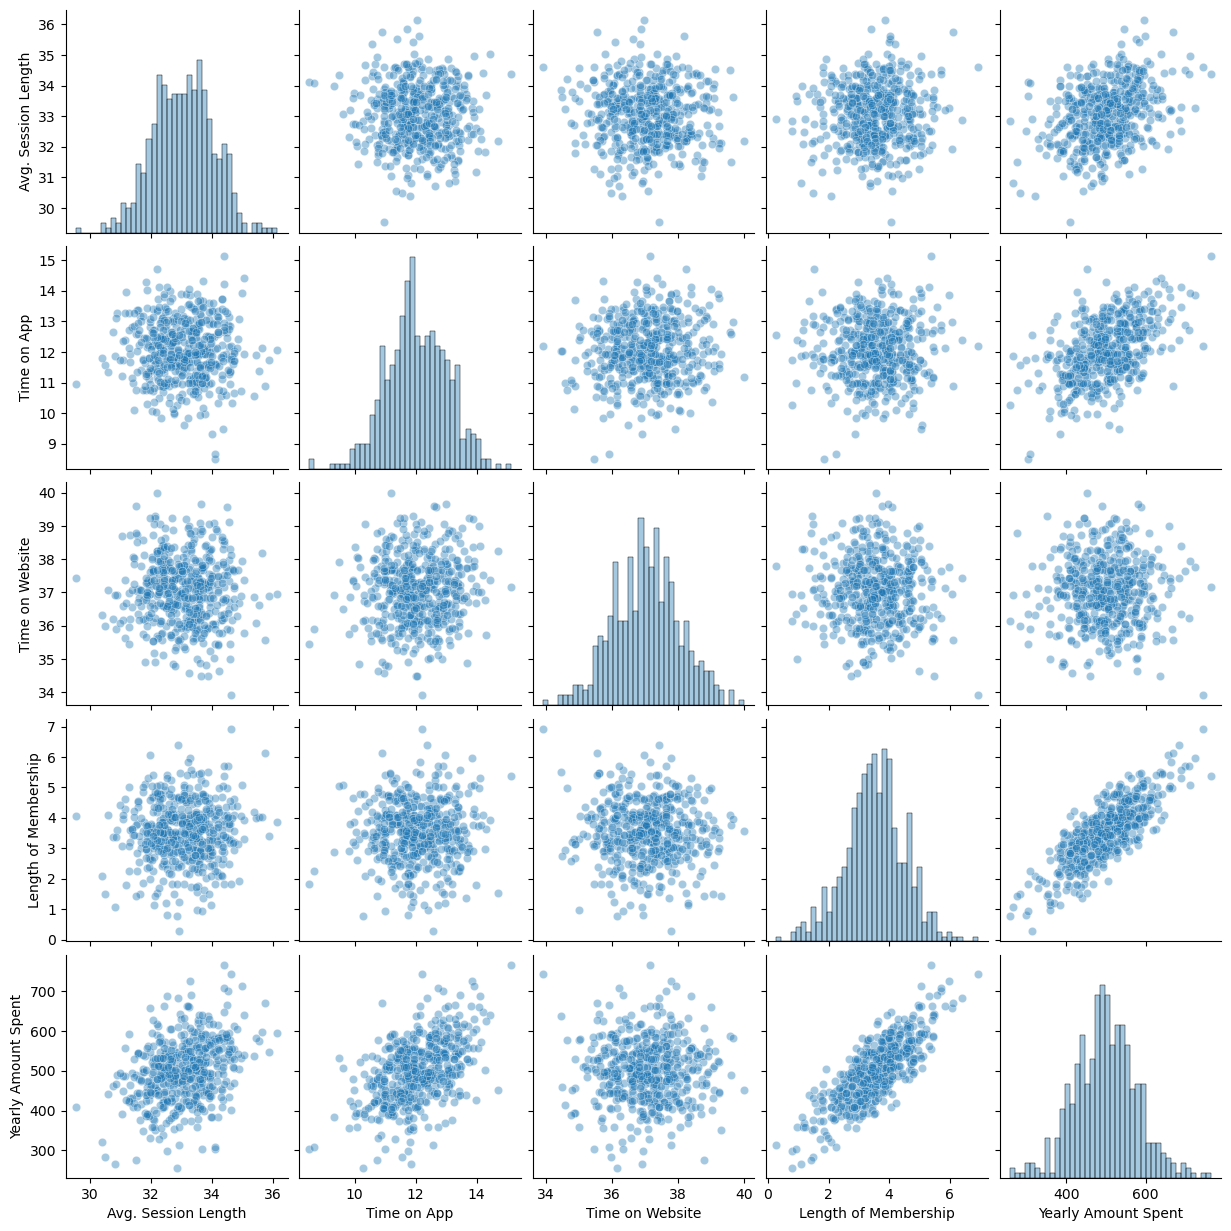

In [38]:
sns.pairplot(data, kind="scatter", plot_kws={'alpha': 0.4}, diag_kws={'alpha': 0.4, 'bins': 40});

## EDA Summary

From the exploratory analysis, we observed different levels of correlation between the features and the target variable **Yearly Amount Spent**.

Among all variables, **Avg. Session Length** shows the strongest correlation with the target variable, suggesting that customers who spend more time per session tend to spend more money annually.

However, since the objective of this project is to analyze the influence of both **Time on App** and **Time on Website**, these features will still be included in the modeling process. Even if their individual correlations are lower, machine learning models can capture combined effects between multiple variables.

Therefore, in the next phase, we will build and compare **Linear Regression models** using both **scikit-learn** and **mlforge-studio** to evaluate how these features contribute to predicting customer spending.


## Data Preprocessing

Before training the machine learning models, the dataset needs to be prepared to ensure that it can be properly used by the algorithms.

During the exploratory data analysis phase, we observed that the dataset does not contain any missing values, which simplifies the preprocessing step. However, some features in the dataset are **non-numerical**, such as:

* Email
* Address
* Avatar

Since linear regression models require **numerical input features**, these columns cannot be directly used in the modeling process. Therefore, they will be removed from the dataset.

In this phase, we will focus on preparing the data by keeping only the relevant numerical features that can be used to train our regression models.


In [39]:
data = data.drop(['Email', 'Address', 'Avatar'], axis=1)

In [40]:
X = data.drop("Yearly Amount Spent", axis=1)
y = data['Yearly Amount Spent']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Preprocessing Summary

After preprocessing the dataset, all non-numerical features have been removed, leaving only the numerical variables relevant for the regression model.

The remaining features include:

* Avg. Session Length
* Time on App
* Time on Website
* Length of Membership

The target variable for this project is:

* **Yearly Amount Spent**

The dataset is now properly structured and ready for the next phase of the project: **training the Linear Regression models**. In the following section, we will train and compare two implementations of linear regression using **scikit-learn** and the **mlforge-studio** framework.


## Model Training

After preparing the dataset, the next step is to train machine learning models to predict the **Yearly Amount Spent** based on customer activity features.

In this project, we will train two implementations of **Linear Regression**:

* A model implemented using **scikit-learn**, one of the most widely used machine learning libraries in Python.
* A model implemented using **mlforge-studio**, a custom machine learning framework designed to simplify experimentation and model development.

Both models will be trained on the same dataset and using the same features to ensure a fair comparison. The goal is to observe how each implementation performs when predicting customer spending.


In [41]:
# Training scikit-learn linear regression model 
sk_model = LinearRegression()
sk_model.fit(X=X_train, y=y_train)

# Predictions for X test values
sk_predictions = sk_model.predict(X=X_test)

In [42]:
# Training mlforge-studio linear regression (closed form version) model
mlforge_model = LinearRegressionClosedForm()
mlforge_model.fit(X=X_train, y=y_train)

# Predicting X test values 
mlforge_predictions = mlforge_model.predict(X=X_test)

## Model Evaluation

To evaluate the performance of the trained models, we use the **R² score (coefficient of determination)**.

The R² score measures how well the model explains the variance of the target variable. Its value ranges between **0 and 1**, where:

* **1** indicates a perfect prediction
* **0** indicates that the model does not explain the data better than a simple average

By calculating the R² score for both models, we can assess how accurately they predict the **Yearly Amount Spent** and compare their performance.


In [43]:
sk_model.coef_

array([25.5962591 , 38.78534598,  0.31038593, 61.89682859])

In [44]:
mlforge_model.coef_

array([25.5962591 , 38.78534598,  0.31038593, 61.89682859])

In [45]:
sk_r2 = r2_score(y_true=y_test, y_pred=sk_predictions)
sk_mse = mean_squared_error(y_true=y_test, y_pred=sk_predictions)
sk_mae = mean_absolute_error(y_true=y_test, y_pred=sk_predictions)

In [46]:
print("Sklearn R2: ", sk_r2) 
print("Sklearn MSE: ", sk_mse) # MSE: Mean Squared Error
print("Sklearn MAE: ", sk_mae) # MAE: Mean Absolute Error
print("Sklearn RMSE: ", np.sqrt(sk_mse)) # RMSE: Root Mean Squared Error

Sklearn R2:  0.9778130629184126
Sklearn MSE:  109.86374118394004
Sklearn MAE:  8.558441885315244
Sklearn RMSE:  10.481590584636477


In [47]:
mlforge_r2 = r2_score(y_true=y_test, y_pred=mlforge_predictions)
mlforge_mse = mean_squared_error(y_true=y_test, y_pred=mlforge_predictions)
mlforge_mae = mean_absolute_error(y_true=y_test, y_pred=mlforge_predictions)

In [48]:
print("MLForge R2: ", mlforge_r2) 
print("MLForge MSE: ", mlforge_mse) # MSE: Mean Squared Error
print("MLForge MAE: ", mlforge_mae) # MAE: Mean Absolute Error
print("MLForge RMSE: ", np.sqrt(mlforge_mse)) # RMSE: Root Mean Squared Error

MLForge R2:  0.9778130629183965
MLForge MSE:  109.86374118402007
MLForge MAE:  8.558441885320299
MLForge RMSE:  10.481590584640294


In [49]:
results = pd.DataFrame({
    "Model": ["Scikit-learn Linear Regression", "MLForge Linear Regression"],
    "R2 Score": [sk_r2, mlforge_r2]
})

results

,Model,R2 Score
0,Scikit-learn Linear Regression,0.977813
1,MLForge Linear Regression,0.977813


In [50]:
sk_residuals = y_test - sk_predictions

In [51]:
sk_residuals

361    -1.829165
73     -7.756069
374    -8.017377
155     2.064515
104     0.402956
         ...    
347     4.827772
86      2.197933
75     22.788656
438    -5.685951
15     10.072051
Name: Yearly Amount Spent, Length: 100, dtype: float64

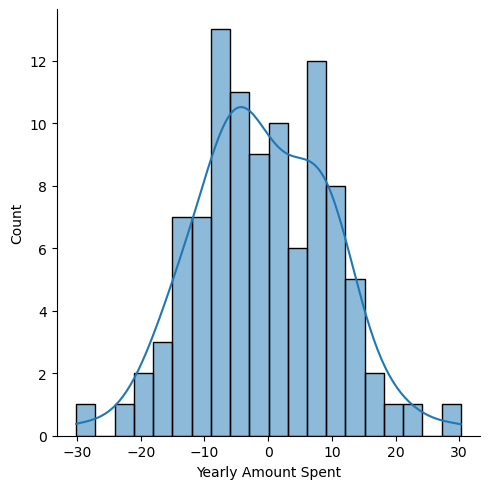

In [52]:
sns.displot(sk_residuals, bins=20, kde=True);

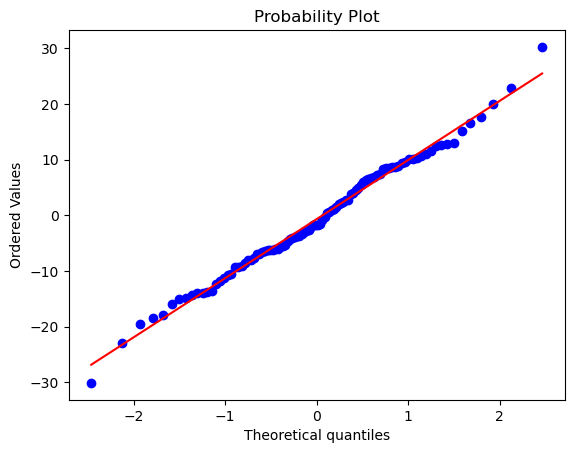

In [53]:
import pylab
import scipy.stats as stats
stats.probplot(sk_residuals, dist="norm", plot=pylab)
pylab.show()

In [54]:
mlforge_residuals = y_test - mlforge_predictions

In [55]:
mlforge_residuals

361    -1.829165
73     -7.756069
374    -8.017377
155     2.064515
104     0.402956
         ...    
347     4.827772
86      2.197933
75     22.788656
438    -5.685951
15     10.072051
Name: Yearly Amount Spent, Length: 100, dtype: float64

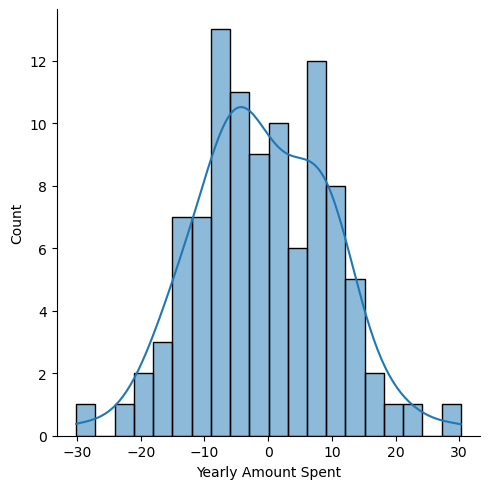

In [56]:
sns.displot(mlforge_residuals, bins=20, kde=True);

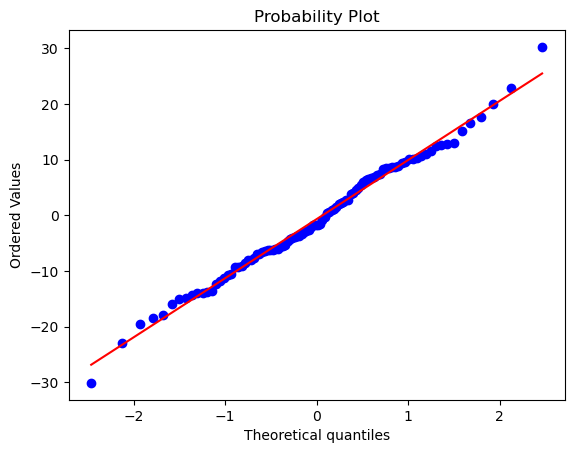

In [57]:
import pylab
import scipy.stats as stats
stats.probplot(mlforge_residuals, dist="norm", plot=pylab)
pylab.show()

## Model Comparison & Conclusion

After training and evaluating both models, we observe that the **mlforge-studio implementation produces exactly the same results as scikit-learn** for Linear Regression. Both the predictions and R² scores are identical, confirming that mlforge-studio reliably replicates standard linear regression workflows.

When categorizing customers by platform usage, we observe the following distribution:

In [58]:
# Calculer la moyenne du temps passé sur App
app_mean = data['Time on App'].mean()

# Marquer les clients qui passent plus de temps que la moyenne sur l'App
data['Platform'] = data['Time on App'].apply(
    lambda x: 'App' if x > app_mean else 'Website'
)

# Vérifier la répartition
print(data['Platform'].value_counts())

Platform
Website    262
App        238
Name: count, dtype: int64


This shows that a significant portion of customers actively use the mobile application. Importantly, customers who spend more time on the **mobile app tend to spend more annually** compared to those primarily using the website.

From a business perspective, these insights suggest that **investing in improving and promoting the mobile app** could increase customer spending and overall revenue.

In summary:

- Both models are **accurate and consistent**, demonstrating the reliability of mlforge-studio.  
- **Website users spend more** than App users.  
- Linear Regression effectively predicts customer spending and provides actionable business insights.